# Índice de otoñalidad cinematográfica 🍂

Este notebook prepara el universo inicial de películas y deja lista la estructura de trabajo para diseñar un índice de otoñalidad.

**Alcance:** películas asociadas al otoño sin usar Halloween como criterio de inclusión.  
**Unidad de análisis:** una película.  
**Fuente inicial:** `peliculas_otono_candidatas.csv`.

> El notebook no decide todavía las variables, escalas ni pesos del índice. Esas decisiones se documentarán antes de calcularlo.

## 1. Preparación

In [1]:
# importo las herramientas que voy a utilizar
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 100)

In [2]:
# defino las rutas de trabajo a partir de la carpeta del notebook
DATA_DIR = Path.cwd()
CSV_PATH = DATA_DIR / "peliculas_otono_candidatas.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(f"No se encuentra el archivo: {CSV_PATH}")

CSV_PATH

WindowsPath('c:/Users/rober/OneDrive/Documentos/Bootcamp The Bridge/peliculas_otono/peliculas_otono_candidatas.csv')

## 2. Carga del universo inicial

In [3]:
# cargo el universo inicial de películas
peliculas = pd.read_csv(CSV_PATH)

peliculas.head()

,candidate_id,titulo_castellano,titulo_original,release_year
0,1,Cuando Harry encontró a Sally,When Harry Met Sally...,1989
1,2,Tienes un e-mail,You've Got Mail,1998
2,3,Otoño en Nueva York,Autumn in New York,2000
3,4,Quédate a mi lado,Stepmom,1998
4,5,Cielo de octubre,October Sky,1999


In [4]:
# reviso el tamaño y los tipos detectados durante la carga
print(f"Películas: {len(peliculas):,}")
print(f"Columnas: {peliculas.shape[1]}")
peliculas.info()

Películas: 265
Columnas: 4
<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   candidate_id       265 non-null    int64
 1   titulo_castellano  265 non-null    str  
 2   titulo_original    265 non-null    str  
 3   release_year       265 non-null    int64
dtypes: int64(2), str(2)
memory usage: 17.3 KB


## 3. Comprobaciones de calidad

Antes de enriquecer los datos comprobamos el esquema, los valores ausentes y posibles duplicados.

In [5]:
# compruebo que el archivo mantiene el esquema que espero
COLUMNAS_ESPERADAS = [
    "candidate_id",
    "titulo_castellano",
    "titulo_original",
    "release_year",
]

columnas_faltantes = sorted(set(COLUMNAS_ESPERADAS) - set(peliculas.columns))
columnas_inesperadas = sorted(set(peliculas.columns) - set(COLUMNAS_ESPERADAS))

assert not columnas_faltantes, f"Faltan columnas: {columnas_faltantes}"
print("Columnas inesperadas:", columnas_inesperadas or "ninguna")

Columnas inesperadas: ninguna


In [6]:
# resumo la calidad de cada columna
resumen_calidad = pd.DataFrame({
    "tipo": peliculas.dtypes.astype(str),
    "nulos": peliculas.isna().sum(),
    "porcentaje_nulos": peliculas.isna().mean().mul(100).round(2),
    "valores_unicos": peliculas.nunique(dropna=True),
})

resumen_calidad

,tipo,nulos,porcentaje_nulos,valores_unicos
candidate_id,int64,0,0.0,265
titulo_castellano,str,0,0.0,259
titulo_original,str,0,0.0,259
release_year,int64,0,0.0,64


In [7]:
# busco identificadores y películas repetidas sin eliminar ninguna fila
duplicados_id = peliculas[peliculas.duplicated("candidate_id", keep=False)]
duplicados_pelicula = peliculas[
    peliculas.duplicated(["titulo_original", "release_year"], keep=False)
].sort_values(["titulo_original", "release_year"])

print(f"IDs duplicados: {len(duplicados_id)}")
print(f"Filas con título original y año duplicados: {len(duplicados_pelicula)}")
duplicados_pelicula

IDs duplicados: 0
Filas con título original y año duplicados: 0


,candidate_id,titulo_castellano,titulo_original,release_year


## 4. Normalización mínima

Solo corregimos tipos y espacios accidentales. No modificamos títulos ni eliminamos candidatos automáticamente.

In [8]:
# creo una copia para conservar intactos los datos originales
peliculas_limpias = peliculas.copy()

peliculas_limpias["candidate_id"] = pd.to_numeric(
    peliculas_limpias["candidate_id"], errors="raise"
).astype("int64")

peliculas_limpias["release_year"] = pd.to_numeric(
    peliculas_limpias["release_year"], errors="coerce"
).astype("Int64")

columnas_texto = ["titulo_castellano", "titulo_original"]
peliculas_limpias[columnas_texto] = peliculas_limpias[columnas_texto].apply(
    lambda serie: serie.astype("string").str.strip()
)

peliculas_limpias.head()

,candidate_id,titulo_castellano,titulo_original,release_year
0,1,Cuando Harry encontró a Sally,When Harry Met Sally...,1989
1,2,Tienes un e-mail,You've Got Mail,1998
2,3,Otoño en Nueva York,Autumn in New York,2000
3,4,Quédate a mi lado,Stepmom,1998
4,5,Cielo de octubre,October Sky,1999


## 5. Primera fotografía del conjunto

In [9]:
# observo el rango temporal y la distribución por décadas
rango_temporal = (
    peliculas_limpias["release_year"].min(),
    peliculas_limpias["release_year"].max(),
)

print(f"Rango temporal: {rango_temporal[0]}–{rango_temporal[1]}")

peliculas_limpias.assign(
    decada=(peliculas_limpias["release_year"] // 10 * 10).astype("Int64")
)["decada"].value_counts().sort_index().rename_axis("década").to_frame("películas")

Rango temporal: 1933–2024


,películas
década,
1930,1
1940,8
1950,5
1960,6
1970,12
1980,38
1990,71
2000,65
2010,47


## 6. Diseño del índice: decisiones metodológicas

Antes de añadir nuevas columnas al conjunto de datos, conviene definir y justificar las decisiones metodológicas que determinarán la construcción del índice:

1. ¿Qué dimensiones definen la otoñalidad: estación narrativa, color, clima, paisaje, vestuario, tono o espacios acogedores?
2. ¿Qué variables podrán observarse automáticamente y cuáles requerirán codificación manual?
3. ¿Qué escala tendrá cada variable?
4. ¿Cómo evitaremos puntuar dos veces un mismo fenómeno mediante variables muy correlacionadas?
5. ¿Habrá criterios de exclusión, como que Halloween sea un elemento central de la trama?
6. ¿Las dimensiones tendrán el mismo peso o se utilizarán pesos teóricos o derivados de evaluaciones humanas?

### Hipótesis inicial

Considero que una película es otoñal cuando el otoño es reconocible en su ambientación narrativa o visual y esta sensación se refuerza mediante el paisaje, la paleta cromática, el clima, el vestuario, las actividades estacionales o el tono emocional.

La presencia aislada de uno de estos elementos no será suficiente para obtener una puntuación alta: la otoñalidad debe aparecer de forma recurrente o desempeñar un papel relevante en la experiencia de la película.

Por tanto, una película obtendrá una puntuación elevada cuando el otoño no funcione únicamente como fondo, sino como una parte significativa de su identidad visual, narrativa o emocional.

### Dimensiones del índice

El índice estará compuesto inicialmente por cinco dimensiones:

| Variable | Definición |
|---|---|
| `presencia_otono` | Mide si la historia sucede explícitamente durante el otoño y la importancia que tiene la estación dentro de la narración. |
| `paisaje_paleta` | Mide la presencia de follaje, hojas caídas, bosques y colores ocres, marrones, rojos o naranjas. |
| `clima_vestuario` | Mide la presencia de lluvia, niebla, viento, temperaturas frescas, abrigos, jerséis y bufandas. |
| `rituales_espacios` | Mide la presencia de actividades y espacios asociados al otoño, como la vuelta al colegio, la cosecha, Acción de Gracias, cafeterías, librerías o chimeneas. |
| `tono_otonal` | Mide la presencia de nostalgia, melancolía, intimidad, reflexión o calidez emocional. |

### Escala común

Las cinco dimensiones utilizarán una escala ordinal de 0 a 3:

- **0:** el elemento está ausente.
- **1:** su presencia es puntual o débil.
- **2:** su presencia es clara y recurrente.
- **3:** el elemento es dominante o esencial.

El uso de una escala común permitirá comparar las dimensiones y evitará mezclar variables con rangos diferentes.

### Criterios específicos de puntuación

#### Presencia del otoño

Variable: `presencia_otono`

- **0:** la historia no sucede en otoño o la estación no puede determinarse.
- **1:** el otoño aparece brevemente o solamente se intuye.
- **2:** una parte importante de la historia sucede en otoño.
- **3:** el otoño domina la historia o resulta esencial para su desarrollo.

#### Paisaje y paleta cromática

Variable: `paisaje_paleta`

- **0:** no aparecen elementos visuales asociados al otoño.
- **1:** aparecen de forma aislada.
- **2:** aparecen de manera clara y recurrente.
- **3:** definen la identidad visual de la película.

#### Clima y vestuario

Variable: `clima_vestuario`

- **0:** no aparecen señales de clima fresco ni vestuario asociado.
- **1:** estos elementos aparecen ocasionalmente.
- **2:** aparecen con frecuencia.
- **3:** condicionan claramente la ambientación o la historia.

#### Rituales y espacios

Variable: `rituales_espacios`

- **0:** no aparecen actividades ni espacios relacionados con el otoño.
- **1:** aparece algún elemento aislado.
- **2:** aparecen varios elementos o tienen cierta importancia.
- **3:** estos elementos estructuran una parte importante de la película.

#### Tono emocional

Variable: `tono_otonal`

- **0:** no aparecen los tonos emocionales definidos.
- **1:** la sensación de nostalgia, melancolía, intimidad o calidez es débil.
- **2:** estos tonos están presentes de manera clara y recurrente.
- **3:** el tono otoñal domina la experiencia emocional de la película.

### Regla de exclusión de Halloween

Halloween no se utilizará como una puntuación negativa dentro del índice. En su lugar, se creará una variable independiente denominada `halloween_central`:

- **0:** Halloween no es central en la película.
- **1:** Halloween es un elemento central de la trama.

Cuando `halloween_central == 1`, la película quedará fuera del análisis. De esta manera, la exclusión será transparente y no alterará artificialmente las puntuaciones de las demás películas.

La presencia de elementos sobrenaturales, fantásticos, góticos o de terror no será motivo suficiente para excluir una película si Halloween no ocupa un lugar central en su argumento.

### Variables auxiliares

También se incorporarán tres variables que no formarán parte del cálculo del índice:

| Variable | Definición |
|---|---|
| `confianza_codificacion` | Indica si la confianza en la puntuación asignada es baja, media o alta. |
| `fuente_evidencia` | Registra el enlace o la referencia utilizada para evaluar la película. |
| `notas` | Recoge una explicación breve de las puntuaciones o de cualquier decisión relevante. |

Estas variables permitirán distinguir entre películas evaluadas mediante su visionado completo y películas evaluadas mediante sinopsis, tráileres, críticas o fotogramas.

### Ponderación inicial

En la primera versión del índice, las cinco dimensiones tendrán el mismo peso. Cada una representará el 20 % de la puntuación final.

Esta decisión ofrece un punto de partida sencillo y transparente. Posteriormente, se podrá realizar un análisis de sensibilidad para comprobar cómo cambia la clasificación al modificar los pesos.

### Cálculo del índice

La puntuación bruta máxima será de 15 puntos:

\[
3 \text{ puntos} \times 5 \text{ dimensiones} = 15 \text{ puntos}
\]

La puntuación se transformará a una escala de 0 a 100 mediante la siguiente fórmula:

\[
\text{Índice de otoñalidad}
=
\frac{
\text{presencia del otoño}
+
\text{paisaje y paleta}
+
\text{clima y vestuario}
+
\text{rituales y espacios}
+
\text{tono emocional}
}{15}
\times 100
\]

La interpretación inicial será:

- **0–20:** otoñalidad inexistente o muy débil.
- **21–40:** otoñalidad leve.
- **41–60:** otoñalidad moderada.
- **61–80:** película claramente otoñal.
- **81–100:** el otoño domina la identidad de la película.

### Prueba piloto

Antes de aplicar el índice a las 265 películas, se realizará una prueba piloto con aproximadamente diez títulos diferentes entre sí.

Esta prueba permitirá comprobar:

- Si las definiciones son suficientemente claras.
- Si dos películas similares reciben puntuaciones parecidas.
- Si alguna dimensión resulta demasiado subjetiva.
- Si existen variables redundantes.
- Si los criterios permiten distinguir correctamente entre una aparición aislada y una ambientación otoñal dominante.

Las definiciones se revisarán después de esta prueba y antes de iniciar la codificación completa del conjunto de datos.

In [10]:
# guardo las dimensiones que utilizaré para construir el índice
variables_indice = [
    "presencia_otono",
    "paisaje_paleta",
    "clima_vestuario",
    "rituales_espacios",
    "tono_otonal",
]

# guardo por separado las variables de control y documentación
variables_auxiliares = [
    "halloween_central",
    "confianza_codificacion",
    "fuente_evidencia",
    "notas",
]

variables_indice, variables_auxiliares

(['presencia_otono',
  'paisaje_paleta',
  'clima_vestuario',
  'rituales_espacios',
  'tono_otonal'],
 ['halloween_central', 'confianza_codificacion', 'fuente_evidencia', 'notas'])

## 7. Preparación de la tabla de trabajo

Creo una copia del conjunto de datos limpio para conservar intacta la tabla original.

Añado las cinco dimensiones del índice como columnas numéricas inicialmente vacías. También incorporo las variables auxiliares necesarias para aplicar la exclusión de Halloween y documentar las decisiones tomadas durante la codificación.

In [11]:
peliculas_trabajo = peliculas_limpias.copy()

for columna in variables_indice:
    peliculas_trabajo[columna] = pd.Series(
        pd.NA,
        index=peliculas_trabajo.index,
        dtype="Int64",
    )

peliculas_trabajo["halloween_central"] = pd.Series(
    pd.NA,
    index=peliculas_trabajo.index,
    dtype="Int64",
)

for columna in [
    "confianza_codificacion",
    "fuente_evidencia",
    "notas",
]:
    peliculas_trabajo[columna] = pd.Series(
        pd.NA,
        index=peliculas_trabajo.index,
        dtype="string",
    )

peliculas_trabajo.head()

,candidate_id,titulo_castellano,titulo_original,release_year,presencia_otono,paisaje_paleta,clima_vestuario,rituales_espacios,tono_otonal,halloween_central,confianza_codificacion,fuente_evidencia,notas
0,1,Cuando Harry encontró a Sally,When Harry Met Sally...,1989,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2,Tienes un e-mail,You've Got Mail,1998,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,3,Otoño en Nueva York,Autumn in New York,2000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,4,Quédate a mi lado,Stepmom,1998,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,5,Cielo de octubre,October Sky,1999,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## 8. Selección de la muestra piloto

Antes de evaluar las 265 películas, selecciono una muestra de diez títulos con características diferentes.

Incluyo películas de distintas décadas, géneros y niveles previsibles de otoñalidad. Utilizo conjuntamente el título original y el año de estreno para distinguir correctamente las diferentes adaptaciones de una misma obra.

Esta muestra permitirá comprobar si las dimensiones y la escala funcionan antes de aplicarlas al conjunto completo.

In [13]:
seleccion_piloto = pd.DataFrame(
    [
        ("When Harry Met Sally...", 1989),
        ("Fantastic Mr. Fox", 2009),
        ("Autumn Sonata", 1978),
        ("Dead Poets Society", 1989),
        ("Far from Heaven", 2002),
        ("Knives Out", 2019),
        ("The Ice Storm", 1997),
        ("Little Women", 2019),
        ("The Holdovers", 2023),
        ("Spirited Away", 2001),
    ],
    columns=["titulo_original", "release_year"],
)

piloto = seleccion_piloto.merge(
    peliculas_trabajo,
    on=["titulo_original", "release_year"],
    how="left",
    validate="one_to_one",
)

columnas_piloto = [
    "candidate_id",
    "titulo_castellano",
    "titulo_original",
    "release_year",
    *variables_indice,
    *variables_auxiliares,
]

piloto[columnas_piloto]

,candidate_id,titulo_castellano,titulo_original,release_year,presencia_otono,paisaje_paleta,clima_vestuario,rituales_espacios,tono_otonal,halloween_central,confianza_codificacion,fuente_evidencia,notas
0,1,Cuando Harry encontró a Sally,When Harry Met Sally...,1989,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,20,Fantástico Sr. Fox,Fantastic Mr. Fox,2009,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,6,Sonata de otoño,Autumn Sonata,1978,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,7,El club de los poetas muertos,Dead Poets Society,1989,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,15,Lejos del cielo,Far from Heaven,2002,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
5,33,Puñales por la espalda,Knives Out,2019,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
6,38,La tormenta de hielo,The Ice Storm,1997,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
7,251,Mujercitas,Little Women,2019,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
8,157,Los que se quedan,The Holdovers,2023,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
9,56,El viaje de Chihiro,Spirited Away,2001,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## 9. Codificación de la muestra piloto

Evaluaré las diez películas de la muestra piloto individualmente.

Para cada película asignaré una puntuación de 0 a 3 a las cinco dimensiones del índice. También indicaré si Halloween es central en la trama, registraré la fuente utilizada y justificaré brevemente las puntuaciones.

Comienzo con *Cuando Harry encontró a Sally*.

In [14]:
pelicula_actual = piloto.loc[
    piloto["titulo_original"].eq("When Harry Met Sally...")
]

pelicula_actual[
    [
        "candidate_id",
        "titulo_castellano",
        "titulo_original",
        "release_year",
        *variables_indice,
        *variables_auxiliares,
    ]
].T

,0
candidate_id,1
titulo_castellano,Cuando Harry encontró a Sally
titulo_original,When Harry Met Sally...
release_year,1989
presencia_otono,<NA>
paisaje_paleta,<NA>
clima_vestuario,<NA>
rituales_espacios,<NA>
tono_otonal,<NA>
halloween_central,<NA>


### Cuando Harry encontró a Sally

La película recorre distintas estaciones y varios años, por lo que el otoño no domina toda la narración. Sin embargo, las secuencias otoñales de Nueva York, especialmente las ambientadas en Central Park, forman una parte muy reconocible de su identidad visual.

El vestuario de entretiempo aparece con frecuencia y el tono general combina nostalgia, intimidad, romanticismo y calidez. Los espacios interiores contribuyen a esa sensación, aunque no aparecen muchos rituales específicamente relacionados con el otoño.

Halloween no es un elemento central de la trama. La confianza de la codificación es media porque parte de su asociación con el otoño procede de escenas concretas y no de toda la película.

In [15]:
mascara = piloto["titulo_original"].eq(
    "When Harry Met Sally..."
)

piloto.loc[
    mascara,
    [
        "presencia_otono",
        "paisaje_paleta",
        "clima_vestuario",
        "rituales_espacios",
        "tono_otonal",
        "halloween_central",
        "confianza_codificacion",
        "fuente_evidencia",
        "notas",
    ],
] = [
    2,
    2,
    2,
    1,
    3,
    0,
    "media",
    "visionado y análisis de escenas",
    (
        "La historia abarca varias estaciones, pero las "
        "secuencias otoñales de Nueva York, el vestuario "
        "y el tono nostálgico son muy reconocibles."
    ),
]

piloto.loc[mascara, columnas_piloto].T

,0
candidate_id,1
titulo_castellano,Cuando Harry encontró a Sally
titulo_original,When Harry Met Sally...
release_year,1989
presencia_otono,2
paisaje_paleta,2
clima_vestuario,2
rituales_espacios,1
tono_otonal,3
halloween_central,0


### Resultado de la primera codificación

*Cuando Harry encontró a Sally* obtiene puntuaciones medias en la presencia narrativa del otoño, la identidad visual y el clima. Su puntuación más alta corresponde al tono emocional, mientras que la presencia de rituales y espacios específicamente otoñales es más limitada.

La codificación queda documentada con un nivel de confianza medio. Halloween no es un elemento central de la película.

### Segunda película: Fantástico Sr. Fox

Continúo la prueba piloto con *Fantástico Sr. Fox*. Examinaré sus elementos narrativos, su identidad visual, el clima, los espacios, los rituales y el tono emocional antes de asignar las puntuaciones.

In [16]:
pelicula_actual = piloto.loc[
    piloto["titulo_original"].eq("Fantastic Mr. Fox")
]

pelicula_actual[
    [
        "candidate_id",
        "titulo_castellano",
        "titulo_original",
        "release_year",
        *variables_indice,
        *variables_auxiliares,
    ]
].T

,1
candidate_id,20
titulo_castellano,Fantástico Sr. Fox
titulo_original,Fantastic Mr. Fox
release_year,2009
presencia_otono,<NA>
paisaje_paleta,<NA>
clima_vestuario,<NA>
rituales_espacios,<NA>
tono_otonal,<NA>
halloween_central,<NA>


### Fantástico Sr. Fox

La película presenta una identidad visual dominada por tonos naranjas, ocres, amarillos y marrones. Los campos, los árboles, las hojas y los escenarios rurales refuerzan de manera constante esta asociación con el otoño.

La estación no se menciona continuamente de forma explícita, por lo que la presencia narrativa del otoño no alcanza la puntuación máxima. Sin embargo, el paisaje, la paleta cromática y los elementos relacionados con las granjas, la cosecha, la sidra, la comida y los espacios subterráneos tienen una importancia central.

El tono combina calidez familiar, nostalgia, aventura y una ligera melancolía. Halloween no forma parte de la trama.

La confianza de la codificación es alta porque los elementos visuales y narrativos asociados al otoño aparecen de manera clara y recurrente.

In [17]:
mascara = piloto["titulo_original"].eq(
    "Fantastic Mr. Fox"
)

piloto.loc[
    mascara,
    [
        "presencia_otono",
        "paisaje_paleta",
        "clima_vestuario",
        "rituales_espacios",
        "tono_otonal",
        "halloween_central",
        "confianza_codificacion",
        "fuente_evidencia",
        "notas",
    ],
] = [
    2,
    3,
    2,
    3,
    2,
    0,
    "alta",
    "visionado y análisis visual",
    (
        "La paleta ocre, el paisaje rural, las granjas, "
        "la sidra y los motivos de cosecha construyen "
        "una identidad otoñal clara y recurrente."
    ),
]

piloto.loc[mascara, columnas_piloto].T

,1
candidate_id,20
titulo_castellano,Fantástico Sr. Fox
titulo_original,Fantastic Mr. Fox
release_year,2009
presencia_otono,2
paisaje_paleta,3
clima_vestuario,2
rituales_espacios,3
tono_otonal,2
halloween_central,0


## 9. Incorporación de la codificación provisional

Importo la codificación provisional de las 265 películas y la uno con el conjunto de datos limpio mediante `candidate_id`.

El archivo contiene las cinco dimensiones del índice, el criterio de exclusión de Halloween, el nivel de confianza y la documentación de cada evaluación.

Esta codificación constituye una primera aproximación asistida. Antes de utilizarla para publicar resultados, revisaré los registros con confianza baja, las películas excluidas y los valores extremos del índice.

In [18]:
ruta_codificacion = (
    DATA_DIR / "codificacion_otonalidad_provisional.csv"
)

codificacion = pd.read_csv(ruta_codificacion)

peliculas_codificadas = peliculas_limpias.merge(
    codificacion,
    on="candidate_id",
    how="left",
    validate="one_to_one",
)

resumen_codificacion = pd.Series(
    {
        "peliculas": len(peliculas_codificadas),
        "ids_duplicados": (
            peliculas_codificadas["candidate_id"]
            .duplicated()
            .sum()
        ),
        "valores_pendientes": (
            peliculas_codificadas[
                variables_indice + variables_auxiliares
            ]
            .isna()
            .sum()
            .sum()
        ),
        "confianza_alta": (
            peliculas_codificadas[
                "confianza_codificacion"
            ]
            .eq("alta")
            .sum()
        ),
        "confianza_media": (
            peliculas_codificadas[
                "confianza_codificacion"
            ]
            .eq("media")
            .sum()
        ),
        "confianza_baja": (
            peliculas_codificadas[
                "confianza_codificacion"
            ]
            .eq("baja")
            .sum()
        ),
        "halloween_central": (
            peliculas_codificadas["halloween_central"]
            .eq(1)
            .sum()
        ),
    },
    name="resultado",
)

resumen_codificacion

peliculas             265
ids_duplicados          0
valores_pendientes      0
confianza_alta         70
confianza_media       185
confianza_baja         10
halloween_central       1
Name: resultado, dtype: int64

## 10. Cálculo del índice de otoñalidad

Para calcular el índice:

1. Excluyo las películas en las que Halloween es un elemento central.
2. Sumo las cinco dimensiones, puntuadas entre 0 y 3.
3. Transformo la puntuación bruta a una escala de 0 a 100.

La puntuación máxima posible es de **15 puntos**. Todas las dimensiones tienen el mismo peso y representan un **20 % del resultado final**.

> **Índice de otoñalidad = (puntuación obtenida / 15) × 100**

In [19]:
peliculas_analisis = peliculas_codificadas.loc[
    peliculas_codificadas["halloween_central"].eq(0)
].copy()

peliculas_analisis["puntuacion_bruta"] = (
    peliculas_analisis[variables_indice]
    .sum(axis=1)
)

peliculas_analisis["indice_otonalidad"] = (
    peliculas_analisis["puntuacion_bruta"]
    .div(15)
    .mul(100)
    .round(1)
)

peliculas_analisis["indice_otonalidad"].describe()

count    264.000000
mean      69.682576
std       11.257829
min       33.300000
25%       66.700000
50%       66.700000
75%       74.975000
max       86.700000
Name: indice_otonalidad, dtype: float64

### Distribución del índice

El índice presenta una media de 69,7 puntos y una mediana de 66,7. La mitad central de las películas se sitúa aproximadamente entre 66,7 y 75 puntos.

La puntuación mínima es 33,3 y la máxima es 86,7. Ninguna película alcanza los extremos teóricos de 0 o 100.

Para conocer el grado de concentración de los resultados, represento la distribución mediante un histograma e indico la media y la mediana.

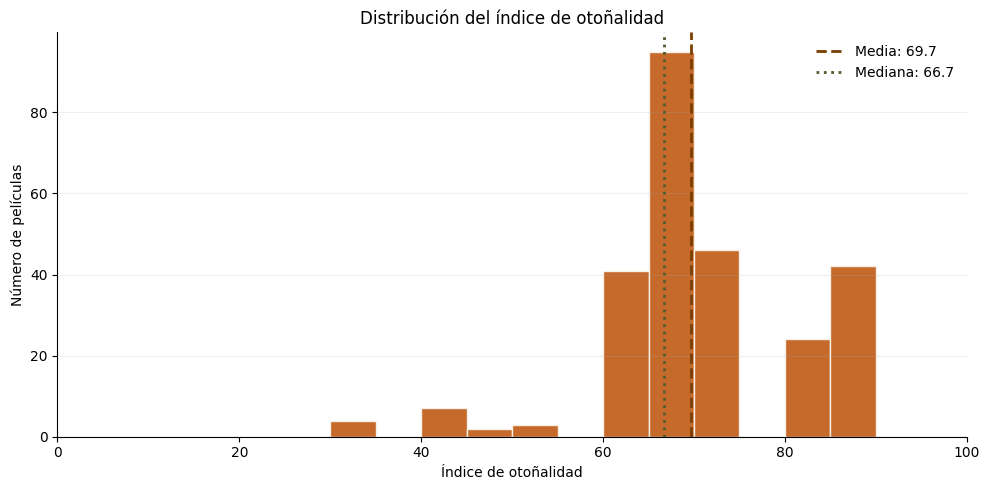

In [20]:
import matplotlib.pyplot as plt

media_indice = peliculas_analisis[
    "indice_otonalidad"
].mean()

mediana_indice = peliculas_analisis[
    "indice_otonalidad"
].median()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    peliculas_analisis["indice_otonalidad"],
    bins=range(0, 105, 5),
    color="#c66a2b",
    edgecolor="#f7f0e6",
)

ax.axvline(
    media_indice,
    color="#7a3e00",
    linestyle="--",
    linewidth=2,
    label=f"Media: {media_indice:.1f}",
)

ax.axvline(
    mediana_indice,
    color="#4f5d2f",
    linestyle=":",
    linewidth=2,
    label=f"Mediana: {mediana_indice:.1f}",
)

ax.set(
    title="Distribución del índice de otoñalidad",
    xlabel="Índice de otoñalidad",
    ylabel="Número de películas",
    xlim=(0, 100),
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### Revisión de los patrones de puntuación

La distribución presenta grandes concentraciones en unas pocas puntuaciones y varios intervalos sin películas.

Este comportamiento indica que muchas películas comparten exactamente la misma combinación de valores en las cinco dimensiones. La concentración es consecuencia de la codificación provisional mediante perfiles comunes y no necesariamente de similitudes reales entre todas las películas agrupadas.

Antes de interpretar el índice o construir una clasificación, compruebo cuántos patrones diferentes existen y cuántas películas comparten cada uno.

In [21]:
patrones_puntuacion = (
    peliculas_analisis
    .groupby(
        variables_indice,
        dropna=False,
    )
    .agg(
        peliculas=("candidate_id", "size"),
        indice_otonalidad=(
            "indice_otonalidad",
            "first",
        ),
    )
    .reset_index()
    .sort_values(
        ["peliculas", "indice_otonalidad"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

patrones_puntuacion

,presencia_otono,paisaje_paleta,clima_vestuario,rituales_espacios,tono_otonal,peliculas,indice_otonalidad
0,2,3,2,1,2,47,66.7
1,2,2,2,2,2,46,66.7
2,2,2,2,2,3,45,73.3
3,3,3,2,3,2,42,86.7
4,1,2,2,1,3,40,60.0
5,3,2,2,3,2,23,80.0
6,1,1,1,1,2,7,40.0
7,0,1,1,1,2,3,33.3
8,2,2,2,1,3,2,66.7
9,1,1,2,0,3,2,46.7


### Selección de las películas finalistas

La codificación provisional genera únicamente 17 patrones para 264 películas. Los seis patrones más frecuentes concentran el 92 % del conjunto, por lo que esta primera puntuación no ofrece suficiente variación para construir un ranking individual.

Utilizo esta versión del índice como una fase de cribado. Selecciono como finalistas las películas que alcanzan al menos 80 puntos.

Estas películas serán objeto de una segunda codificación conjunta, más detallada e individualizada. El resto permanecerá en el conjunto de datos, pero no participará en la clasificación final.

In [22]:
peliculas_finalistas = (
    peliculas_analisis.loc[
        peliculas_analisis[
            "indice_otonalidad"
        ].ge(80)
    ]
    .sort_values(
        [
            "indice_otonalidad",
            "titulo_castellano",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

resumen_finalistas = pd.Series(
    {
        "peliculas_finalistas": len(
            peliculas_finalistas
        ),
        "puntuacion_minima": (
            peliculas_finalistas[
                "indice_otonalidad"
            ].min()
        ),
        "puntuacion_maxima": (
            peliculas_finalistas[
                "indice_otonalidad"
            ].max()
        ),
        "patrones_distintos": (
            peliculas_finalistas[
                variables_indice
            ]
            .drop_duplicates()
            .shape[0]
        ),
    },
    name="resultado",
)

resumen_finalistas

peliculas_finalistas    66.0
puntuacion_minima       80.0
puntuacion_maxima       86.7
patrones_distintos       3.0
Name: resultado, dtype: float64

### Inventario de películas finalistas

El primer cribado selecciona 66 películas con puntuaciones comprendidas entre 80 y 86,7 puntos.

Estas películas se distribuyen en solo tres patrones, por lo que todavía existen numerosos empates. Antes de aplicar la segunda codificación, reviso los títulos incluidos para comprobar que el grupo de finalistas sea coherente y detectar posibles falsos positivos.

La siguiente tabla muestra la identidad de cada película y sus puntuaciones provisionales.

In [23]:
columnas_revision = [
    "candidate_id",
    "titulo_castellano",
    "titulo_original",
    "release_year",
    *variables_indice,
    "indice_otonalidad",
    "confianza_codificacion",
]

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_colwidth",
    80,
):
    display(
        peliculas_finalistas[
            columnas_revision
        ]
    )

,candidate_id,titulo_castellano,titulo_original,release_year,presencia_otono,paisaje_paleta,clima_vestuario,rituales_espacios,tono_otonal,indice_otonalidad,confianza_codificacion
0,232,A fuego lento,The Taste of Things,2023,3,3,2,3,2,86.7,alta
1,108,Ana de las Tejas Verdes,Anne of Green Gables,1985,3,3,2,3,2,86.7,alta
2,30,Beneath the Harvest Sky,Beneath the Harvest Sky,2013,3,3,2,3,2,86.7,alta
3,254,Cita en San Luis,Meet Me in St. Louis,1944,3,3,2,3,2,86.7,alta
4,195,Country,Country,1984,3,3,2,3,2,86.7,alta
5,138,Cuando cae el otoño,When Fall Is Coming,2024,3,3,2,3,2,86.7,alta
6,50,Cuento de otoño,A Tale of Autumn,1998,3,3,2,3,2,86.7,alta
7,255,El cuarto mandamiento,The Magnificent Ambersons,1942,3,3,2,3,2,86.7,alta
8,91,El erizo en la niebla,Hedgehog in the Fog,1975,3,3,2,3,2,86.7,alta
9,131,El hombre de mimbre,The Wicker Man,1973,3,3,2,3,2,86.7,alta


## 11. Codificación refinada de las películas finalistas

Importo la segunda codificación de las 66 películas finalistas.

En esta fase mantengo las mismas cinco dimensiones, pero permito incrementos de 0,5 puntos. Esta escala aporta más granularidad sin asumir una precisión excesiva.

Las puntuaciones se han revisado individualmente para corregir los falsos positivos del primer cribado y diferenciar películas que anteriormente compartían un mismo perfil.

Conservo las puntuaciones provisionales para poder comparar ambas fases y calculo un nuevo índice de otoñalidad refinado en una escala de 0 a 100.

In [25]:
ruta_codificacion_refinada = (
    DATA_DIR
    / "codificacion_finalistas_refinada.csv"
)

codificacion_refinada = pd.read_csv(
    ruta_codificacion_refinada
)

finalistas_refinadas = peliculas_finalistas.merge(
    codificacion_refinada,
    on="candidate_id",
    how="left",
    validate="one_to_one",
)

variables_refinadas = [
    "presencia_otono_refinada",
    "paisaje_paleta_refinada",
    "clima_vestuario_refinada",
    "rituales_espacios_refinada",
    "tono_otonal_refinada",
]

finalistas_refinadas[
    "puntuacion_bruta_refinada"
] = (
    finalistas_refinadas[
        variables_refinadas
    ]
    .sum(axis=1)
)

finalistas_refinadas[
    "indice_otonalidad_refinado"
] = (
    finalistas_refinadas[
        "puntuacion_bruta_refinada"
    ]
    .div(15)
    .mul(100)
    .round(1)
)

resumen_refinado = pd.Series(
    {
        "peliculas": len(
            finalistas_refinadas
        ),
        "valores_pendientes": (
            finalistas_refinadas[
                variables_refinadas
            ]
            .isna()
            .sum()
            .sum()
        ),
        "patrones_distintos": (
            finalistas_refinadas[
                variables_refinadas
            ]
            .drop_duplicates()
            .shape[0]
        ),
        "puntuaciones_distintas": (
            finalistas_refinadas[
                "indice_otonalidad_refinado"
            ]
            .nunique()
        ),
        "puntuacion_minima": (
            finalistas_refinadas[
                "indice_otonalidad_refinado"
            ]
            .min()
        ),
        "puntuacion_maxima": (
            finalistas_refinadas[
                "indice_otonalidad_refinado"
            ]
            .max()
        ),
    },
    name="resultado",
)

resumen_refinado

peliculas                 66.0
valores_pendientes         0.0
patrones_distintos        52.0
puntuaciones_distintas    14.0
puntuacion_minima         46.7
puntuacion_maxima         96.7
Name: resultado, dtype: float64

### Distribución de las puntuaciones refinadas

La segunda codificación aumenta considerablemente la variedad de resultados: las 66 películas finalistas se distribuyen entre 52 patrones y 14 puntuaciones diferentes.

Antes de construir la clasificación, compruebo cuántas películas comparten cada valor del índice. Esta revisión permitirá evitar desempates arbitrarios y decidir si el ranking debe mostrar posiciones compartidas.

In [26]:
frecuencias_refinadas = (
    finalistas_refinadas[
        "indice_otonalidad_refinado"
    ]
    .value_counts()
    .sort_index(ascending=False)
    .rename_axis("indice_otonalidad")
    .reset_index(name="peliculas")
)

frecuencias_refinadas["porcentaje"] = (
    frecuencias_refinadas["peliculas"]
    .div(len(finalistas_refinadas))
    .mul(100)
    .round(1)
)

frecuencias_refinadas[
    "peliculas_acumuladas"
] = (
    frecuencias_refinadas["peliculas"]
    .cumsum()
)

frecuencias_refinadas

,indice_otonalidad,peliculas,porcentaje,peliculas_acumuladas
0,96.7,2,3.0,2
1,93.3,1,1.5,3
2,90.0,11,16.7,14
3,86.7,3,4.5,17
4,83.3,7,10.6,24
5,80.0,10,15.2,34
6,76.7,4,6.1,38
7,73.3,5,7.6,43
8,70.0,9,13.6,52
9,63.3,4,6.1,56


### Clasificación con posiciones compartidas

La distribución refinada mantiene algunos empates relevantes. En particular, once películas obtienen 90 puntos, por lo que elaborar un listado limitado a diez títulos exigiría aplicar un criterio de desempate arbitrario.

Para evitarlo, utilizo una clasificación densa. Las películas con la misma puntuación comparten posición y la siguiente puntuación ocupa el puesto inmediatamente posterior.

Presento como grupo superior las películas situadas en las tres primeras posiciones del índice.

In [27]:
finalistas_refinadas[
    "posicion"
] = (
    finalistas_refinadas[
        "indice_otonalidad_refinado"
    ]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)

grupo_superior = (
    finalistas_refinadas.loc[
        finalistas_refinadas[
            "posicion"
        ].le(3)
    ]
    .sort_values(
        [
            "posicion",
            "titulo_castellano",
            "release_year",
        ]
    )
    .reset_index(drop=True)
)

columnas_clasificacion = [
    "posicion",
    "titulo_castellano",
    "titulo_original",
    "release_year",
    *variables_refinadas,
    "indice_otonalidad_refinado",
    "confianza_refinada",
]

grupo_superior[
    columnas_clasificacion
]

,posicion,titulo_castellano,titulo_original,release_year,presencia_otono_refinada,paisaje_paleta_refinada,clima_vestuario_refinada,rituales_espacios_refinada,tono_otonal_refinada,indice_otonalidad_refinado,confianza_refinada
0,1,La tormenta de hielo,The Ice Storm,1997,3.0,2.5,3.0,3.0,3.0,96.7,alta
1,1,Las normas de la casa de la sidra,The Cider House Rules,1999,3.0,3.0,2.5,3.0,3.0,96.7,alta
2,2,Cuando cae el otoño,When Fall Is Coming,2024,3.0,3.0,2.5,2.5,3.0,93.3,alta
3,3,Ana de las Tejas Verdes,Anne of Green Gables,1985,2.5,3.0,2.5,2.5,3.0,90.0,alta
4,3,Beneath the Harvest Sky,Beneath the Harvest Sky,2013,3.0,2.5,2.5,3.0,2.5,90.0,alta
5,3,Cuento de otoño,A Tale of Autumn,1998,3.0,3.0,2.0,3.0,2.5,90.0,alta
6,3,El mito de las huellas dactilares,The Myth of Fingerprints,1997,3.0,2.0,2.5,3.0,3.0,90.0,alta
7,3,Esencia de mujer,Scent of a Woman,1992,3.0,2.0,2.5,3.0,3.0,90.0,alta
8,3,La casa del sí,The House of Yes,1997,3.0,1.5,3.0,3.0,3.0,90.0,alta
9,3,Lejos del cielo,Far from Heaven,2002,3.0,3.0,2.5,2.0,3.0,90.0,alta


### Composición del grupo superior

Las catorce películas del grupo superior alcanzan puntuaciones similares mediante combinaciones diferentes de las cinco dimensiones.

Para comparar sus perfiles, represento las puntuaciones refinadas mediante un mapa de calor. Los tonos más oscuros indican una presencia más intensa de cada componente de la otoñalidad.

Esta visualización permite distinguir, por ejemplo, las películas dominadas por el paisaje y la paleta de aquellas cuya puntuación procede principalmente del clima, los rituales estacionales o el tono emocional.

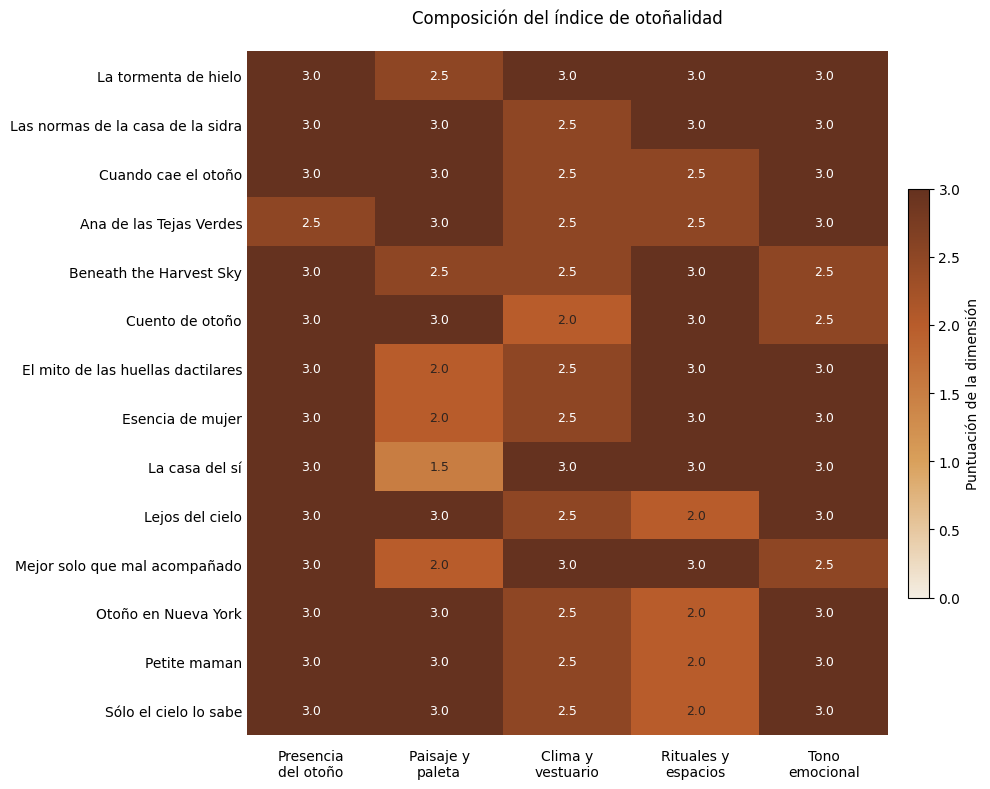

In [28]:
from matplotlib.colors import LinearSegmentedColormap

datos_mapa = (
    grupo_superior
    .set_index("titulo_castellano")[
        variables_refinadas
    ]
    .rename(
        columns={
            "presencia_otono_refinada": "Presencia\ndel otoño",
            "paisaje_paleta_refinada": "Paisaje y\npaleta",
            "clima_vestuario_refinada": "Clima y\nvestuario",
            "rituales_espacios_refinada": "Rituales y\nespacios",
            "tono_otonal_refinada": "Tono\nemocional",
        }
    )
)

colores_otono = LinearSegmentedColormap.from_list(
    "otono",
    [
        "#f4eee3",
        "#d9a05b",
        "#b85c2b",
        "#65321f",
    ],
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

imagen = ax.imshow(
    datos_mapa,
    cmap=colores_otono,
    vmin=0,
    vmax=3,
    aspect="auto",
)

ax.set_xticks(
    range(len(datos_mapa.columns)),
    labels=datos_mapa.columns,
)

ax.set_yticks(
    range(len(datos_mapa.index)),
    labels=datos_mapa.index,
)

for fila in range(len(datos_mapa.index)):
    for columna in range(
        len(datos_mapa.columns)
    ):
        valor = datos_mapa.iloc[
            fila,
            columna,
        ]

        ax.text(
            columna,
            fila,
            f"{valor:.1f}",
            ha="center",
            va="center",
            color=(
                "white"
                if valor >= 2.5
                else "#2f241f"
            ),
            fontsize=9,
        )

ax.set_title(
    "Composición del índice de otoñalidad",
    pad=20,
)

ax.tick_params(
    axis="x",
    length=0,
    pad=10,
)

ax.tick_params(
    axis="y",
    length=0,
)

for borde in ax.spines.values():
    borde.set_visible(False)

barra = fig.colorbar(
    imagen,
    ax=ax,
    fraction=0.03,
    pad=0.03,
)

barra.set_label(
    "Puntuación de la dimensión"
)

plt.tight_layout()
plt.show()

### Clasificación del grupo superior

El mapa de calor muestra que las películas mejor puntuadas no construyen su otoñalidad de la misma manera.

Algunas destacan por el paisaje y la paleta cromática, mientras que otras dependen principalmente del clima, los rituales estacionales o el tono emocional.

Represento las catorce películas del grupo superior mediante un gráfico de barras. Las películas empatadas comparten posición y color.

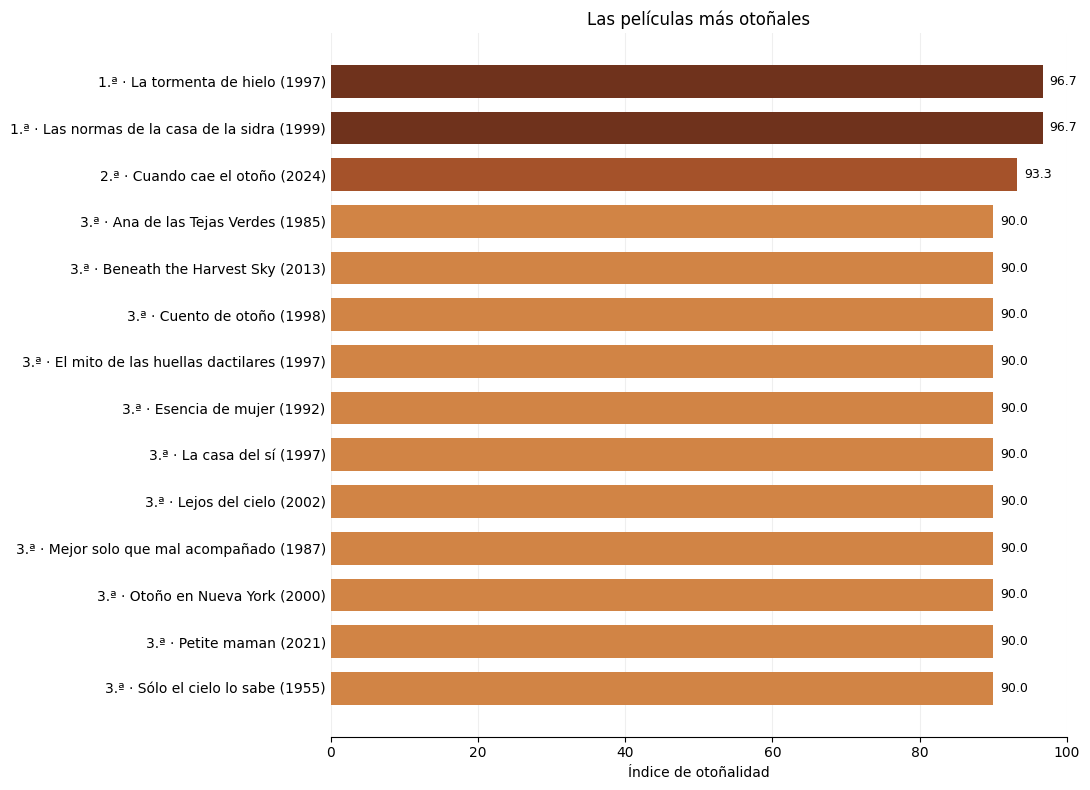

In [29]:
clasificacion_grafico = (
    grupo_superior
    .sort_values(
        [
            "indice_otonalidad_refinado",
            "titulo_castellano",
        ],
        ascending=[True, False],
    )
    .copy()
)

clasificacion_grafico["etiqueta"] = (
    clasificacion_grafico["posicion"]
    .astype(str)
    .add(".ª · ")
    .add(
        clasificacion_grafico[
            "titulo_castellano"
        ]
    )
    .add(" (")
    .add(
        clasificacion_grafico[
            "release_year"
        ].astype(str)
    )
    .add(")")
)

colores_posicion = {
    1: "#6f321c",
    2: "#a5522a",
    3: "#d18445",
}

colores_barras = (
    clasificacion_grafico["posicion"]
    .map(colores_posicion)
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

barras = ax.barh(
    clasificacion_grafico["etiqueta"],
    clasificacion_grafico[
        "indice_otonalidad_refinado"
    ],
    color=colores_barras,
    height=0.7,
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.1f}"
        for valor in clasificacion_grafico[
            "indice_otonalidad_refinado"
        ]
    ],
    padding=5,
    fontsize=9,
)

ax.set(
    title="Las películas más otoñales",
    xlabel="Índice de otoñalidad",
    ylabel="",
    xlim=(0, 100),
)

ax.spines[
    ["top", "right", "left"]
].set_visible(False)

ax.tick_params(
    axis="y",
    length=0,
)

ax.grid(
    axis="x",
    alpha=0.2,
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Comprobación del empate en 90 puntos

La tercera posición está compartida por once películas con un índice de 90 puntos.

Incluyo todas las películas empatadas. No aplico un límite arbitrario de diez títulos, ya que excluir alguna de ellas implicaría utilizar un criterio de desempate ajeno a la metodología del índice.

El grupo superior contiene, por tanto, catorce películas: dos en primera posición, una en segunda y once en tercera.

In [30]:
peliculas_con_90 = (
    finalistas_refinadas.loc[
        finalistas_refinadas[
            "indice_otonalidad_refinado"
        ].eq(90)
    ]
    .sort_values(
        [
            "titulo_castellano",
            "release_year",
        ]
    )
    [
        [
            "titulo_castellano",
            "titulo_original",
            "release_year",
            "indice_otonalidad_refinado",
        ]
    ]
    .reset_index(drop=True)
)

print(
    "películas con 90 puntos:",
    len(peliculas_con_90),
)

peliculas_con_90

películas con 90 puntos: 11


,titulo_castellano,titulo_original,release_year,indice_otonalidad_refinado
0,Ana de las Tejas Verdes,Anne of Green Gables,1985,90.0
1,Beneath the Harvest Sky,Beneath the Harvest Sky,2013,90.0
2,Cuento de otoño,A Tale of Autumn,1998,90.0
3,El mito de las huellas dactilares,The Myth of Fingerprints,1997,90.0
4,Esencia de mujer,Scent of a Woman,1992,90.0
5,La casa del sí,The House of Yes,1997,90.0
6,Lejos del cielo,Far from Heaven,2002,90.0
7,Mejor solo que mal acompañado,"Planes, Trains and Automobiles",1987,90.0
8,Otoño en Nueva York,Autumn in New York,2000,90.0
9,Petite maman,Petite Maman,2021,90.0


### Revisión de las películas próximas al umbral

La clasificación refinada se aplicó inicialmente a las películas que alcanzaron al menos 80 puntos en el cribado provisional.

Para comprobar que el corte no haya excluido candidaturas relevantes, reviso las películas situadas inmediatamente por debajo del umbral. Selecciono aquellas que obtuvieron entre 73,3 y menos de 80 puntos.

Esta comprobación funciona como un análisis de sensibilidad del criterio de selección. Si alguna de estas películas supera los 80 puntos tras una evaluación más detallada, se incorporará al conjunto de finalistas.

In [31]:
candidatas_frontera = (
    peliculas_analisis.loc[
        peliculas_analisis[
            "indice_otonalidad"
        ].between(
            73.3,
            80,
            inclusive="left",
        )
    ]
    .sort_values(
        [
            "indice_otonalidad",
            "titulo_castellano",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

columnas_frontera = [
    "candidate_id",
    "titulo_castellano",
    "titulo_original",
    "release_year",
    *variables_indice,
    "indice_otonalidad",
    "confianza_codificacion",
]

candidatas_frontera[
    columnas_frontera
]

,candidate_id,titulo_castellano,titulo_original,release_year,presencia_otono,paisaje_paleta,clima_vestuario,rituales_espacios,tono_otonal,indice_otonalidad,confianza_codificacion
0,16,Algo para recordar,Sleepless in Seattle,1993,2,2,2,2,3,73.3,media
1,122,"Baby, tú vales mucho",Baby Boom,1987,2,2,2,2,3,73.3,media
2,191,Beautiful Girls,Beautiful Girls,1996,2,2,2,2,3,73.3,media
3,223,Chocolat,Chocolat,2000,2,2,2,2,3,73.3,media
4,60,Coco,Coco,2017,1,3,1,3,3,73.3,alta
5,11,Como la vida misma,Dan in Real Life,2007,2,2,2,2,3,73.3,media
6,41,Conquista a medias,The Half of It,2020,2,2,2,2,3,73.3,media
7,14,Crossing Delancey,Crossing Delancey,1988,2,2,2,2,3,73.3,media
8,49,Dos vidas en un instante,Sliding Doors,1998,2,2,2,2,3,73.3,media
9,8,El indomable Will Hunting,Good Will Hunting,1997,2,2,2,2,3,73.3,media


### Revisión de posibles falsos negativos

La primera selección se basó en una codificación provisional que agrupaba numerosas películas bajo perfiles idénticos. Para comprobar que este procedimiento no había dejado fuera películas especialmente otoñales, realizo una segunda evaluación de las 46 candidatas situadas inmediatamente por debajo del umbral inicial.

En esta revisión utilizo puntuaciones individuales con incrementos de medio punto y aplico las mismas cinco dimensiones del índice. Considero nuevas integrantes del grupo superior aquellas películas cuyo índice refinado alcanza al menos 90 puntos.

In [32]:
ruta_frontera = DATA_DIR / "codificacion_frontera_refinada.csv"

codificacion_frontera = pd.read_csv(ruta_frontera)

columnas_identificacion = [
    "candidate_id",
    "titulo_castellano",
    "titulo_original",
    "release_year",
]

variables_frontera = [
    "presencia_otono_refinada",
    "paisaje_paleta_refinada",
    "clima_vestuario_refinada",
    "rituales_espacios_refinada",
    "tono_otonal_refinada",
]

frontera_refinada = peliculas[columnas_identificacion].merge(
    codificacion_frontera,
    on="candidate_id",
    how="inner",
    validate="one_to_one",
)

frontera_refinada["indice_otonalidad_refinado"] = (
    frontera_refinada[variables_frontera].sum(axis=1) / 15 * 100
).round(1)

nuevas_finalistas = (
    frontera_refinada[
        frontera_refinada["indice_otonalidad_refinado"] >= 90
    ]
    .sort_values(
        ["indice_otonalidad_refinado", "titulo_castellano"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

print(f"películas revisadas: {len(frontera_refinada)}")
print(f"nuevas películas con 90 puntos o más: {len(nuevas_finalistas)}")

nuevas_finalistas[
    [
        "candidate_id",
        "titulo_castellano",
        "titulo_original",
        "release_year",
        "indice_otonalidad_refinado",
        "confianza_refinada",
    ]
]

películas revisadas: 46
nuevas películas con 90 puntos o más: 4


,candidate_id,titulo_castellano,titulo_original,release_year,indice_otonalidad_refinado,confianza_refinada
0,36,Hannah y sus hermanas,Hannah and Her Sisters,1986,90.0,alta
1,51,Prácticamente magia,Practical Magic,1998,90.0,alta
2,4,Quédate a mi lado,Stepmom,1998,90.0,alta
3,2,Tienes un e-mail,You've Got Mail,1998,90.0,alta


### Clasificación superior definitiva

La revisión de las películas próximas al umbral recupera cuatro títulos que también alcanzan los 90 puntos: *Hannah y sus hermanas*, *Prácticamente magia*, *Quédate a mi lado* y *Tienes un e-mail*.

Este resultado demuestra que el cribado provisional era útil para reducir el número de películas, pero no suficientemente preciso para determinar por sí solo la clasificación final.

A continuación, uno las dos codificaciones refinadas, elimino cualquier posible duplicado y construyo el grupo superior definitivo. Las posiciones se calculan mediante una clasificación densa, por lo que las películas con la misma puntuación comparten puesto.

In [33]:
ruta_finalistas = DATA_DIR / "codificacion_finalistas_refinada.csv"
ruta_frontera = DATA_DIR / "codificacion_frontera_refinada.csv"

codificacion_finalistas = pd.read_csv(ruta_finalistas)
codificacion_frontera = pd.read_csv(ruta_frontera)

codificaciones_refinadas = pd.concat(
    [codificacion_finalistas, codificacion_frontera],
    ignore_index=True,
)

codificaciones_refinadas = codificaciones_refinadas.drop_duplicates(
    subset="candidate_id",
    keep="last",
)

ranking_refinado = peliculas[columnas_identificacion].merge(
    codificaciones_refinadas,
    on="candidate_id",
    how="inner",
    validate="one_to_one",
)

ranking_refinado["indice_otonalidad_refinado"] = (
    ranking_refinado[variables_frontera].sum(axis=1) / 15 * 100
).round(1)

grupo_superior = (
    ranking_refinado[
        ranking_refinado["indice_otonalidad_refinado"] >= 90
    ]
    .sort_values(
        ["indice_otonalidad_refinado", "titulo_castellano"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

grupo_superior["posicion"] = (
    grupo_superior["indice_otonalidad_refinado"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

grupo_superior[
    [
        "posicion",
        "titulo_castellano",
        "titulo_original",
        "release_year",
        "indice_otonalidad_refinado",
        "confianza_refinada",
    ]
]

,posicion,titulo_castellano,titulo_original,release_year,indice_otonalidad_refinado,confianza_refinada
0,1,La tormenta de hielo,The Ice Storm,1997,96.7,alta
1,1,Las normas de la casa de la sidra,The Cider House Rules,1999,96.7,alta
2,2,Cuando cae el otoño,When Fall Is Coming,2024,93.3,alta
3,3,Ana de las Tejas Verdes,Anne of Green Gables,1985,90.0,alta
4,3,Beneath the Harvest Sky,Beneath the Harvest Sky,2013,90.0,alta
5,3,Cuento de otoño,A Tale of Autumn,1998,90.0,alta
6,3,El mito de las huellas dactilares,The Myth of Fingerprints,1997,90.0,alta
7,3,Esencia de mujer,Scent of a Woman,1992,90.0,alta
8,3,Hannah y sus hermanas,Hannah and Her Sisters,1986,90.0,alta
9,3,La casa del sí,The House of Yes,1997,90.0,alta


### Representación de la clasificación definitiva

El grupo superior está formado por 18 películas distribuidas en tres posiciones:

- Dos películas comparten el primer puesto con 96,7 puntos.
- Una película ocupa el segundo puesto con 93,3 puntos.
- Quince películas comparten el tercer puesto con 90 puntos.

El orden alfabético utilizado dentro de cada empate no representa diferencias de otoñalidad. Todas las películas con la misma puntuación ocupan la misma posición.

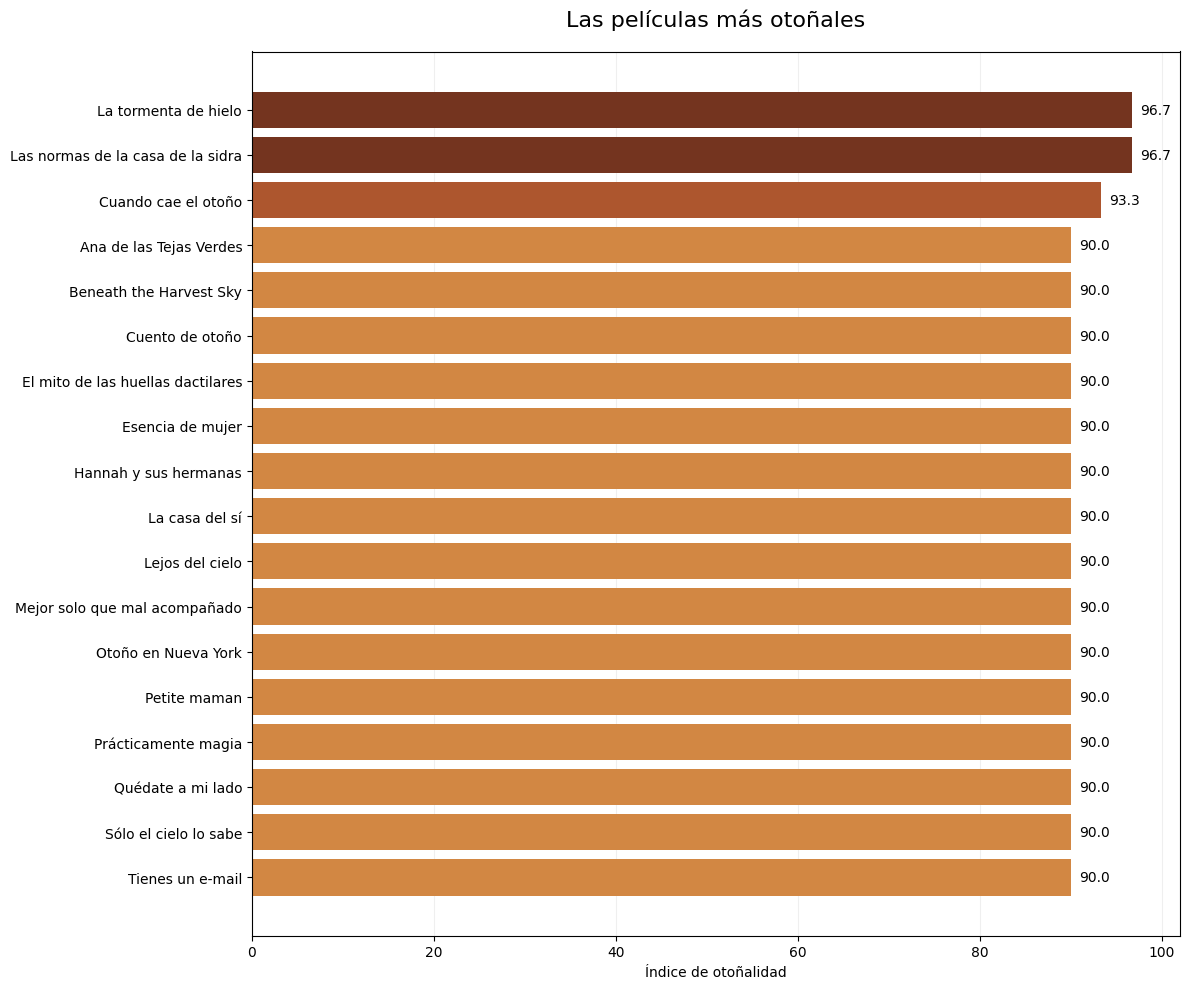

In [35]:
etiquetas = grupo_superior["titulo_castellano"]

colores = grupo_superior["indice_otonalidad_refinado"].map(
    {
        96.7: "#74341f",
        93.3: "#ad562e",
        90.0: "#d28743",
    }
)

fig, ax = plt.subplots(figsize=(12, 10))

barras = ax.barh(
    etiquetas,
    grupo_superior["indice_otonalidad_refinado"],
    color=colores,
)

ax.bar_label(
    barras,
    fmt="%.1f",
    padding=6,
)

ax.set_title(
    "Las películas más otoñales",
    fontsize=16,
    pad=18,
)

ax.set_xlabel("Índice de otoñalidad")
ax.set_ylabel("")
ax.set_xlim(0, 102)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Composición del grupo superior

La puntuación total permite ordenar las películas, pero no muestra qué dimensiones explican el resultado. Dos títulos con el mismo índice pueden alcanzar esa puntuación mediante combinaciones diferentes de paisaje, clima, rituales, tono o presencia explícita del otoño.

El siguiente mapa de calor representa la composición interna del índice para las 18 películas del grupo superior. Los valores más oscuros indican una mayor puntuación en la dimensión correspondiente.

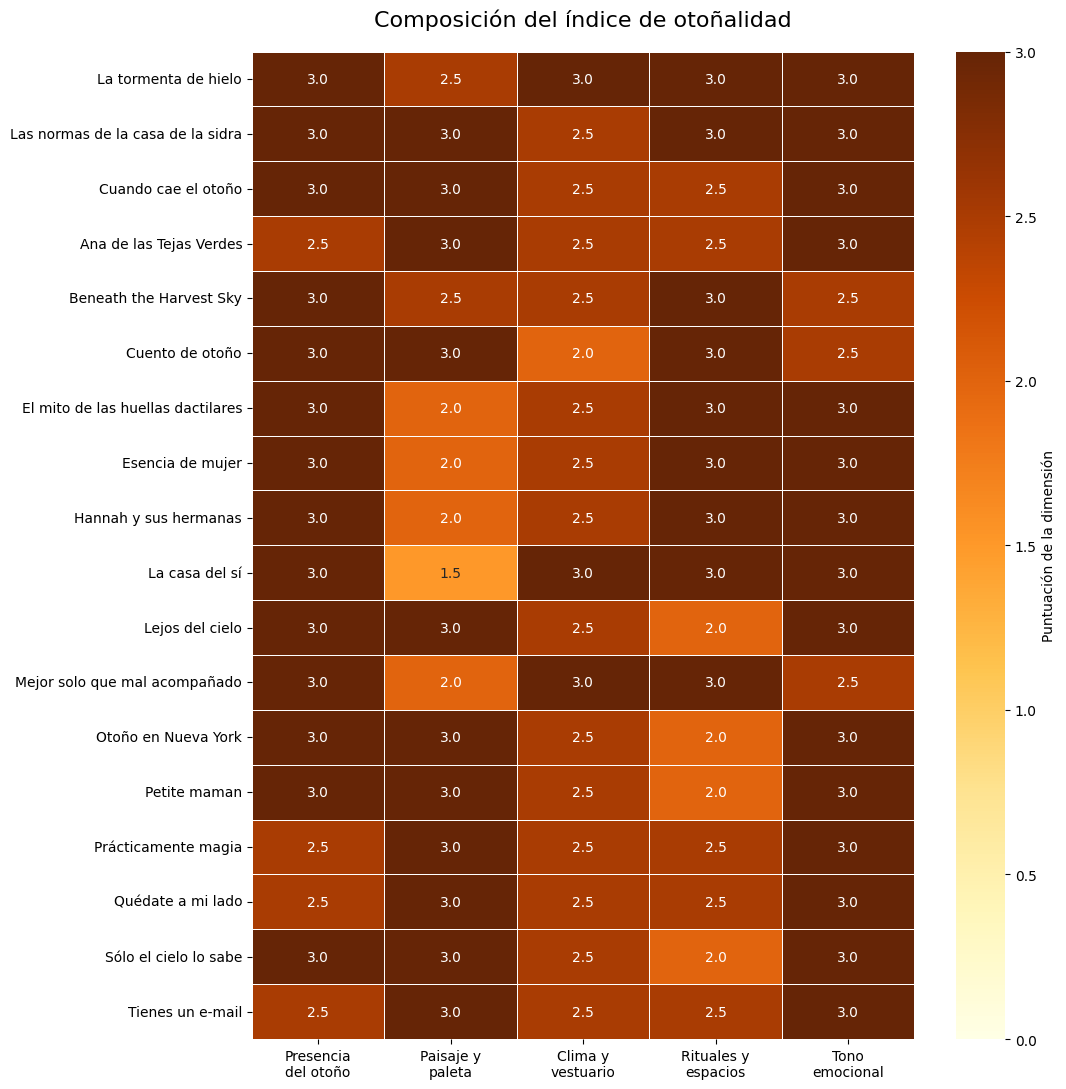

In [38]:
import seaborn as sns

matriz_composicion = (
    grupo_superior
    .set_index("titulo_castellano")[variables_frontera]
    .rename(
        columns={
            "presencia_otono_refinada": "Presencia\ndel otoño",
            "paisaje_paleta_refinada": "Paisaje y\npaleta",
            "clima_vestuario_refinada": "Clima y\nvestuario",
            "rituales_espacios_refinada": "Rituales y\nespacios",
            "tono_otonal_refinada": "Tono\nemocional",
        }
    )
)

plt.figure(figsize=(11, 11))

sns.heatmap(
    matriz_composicion,
    annot=True,
    fmt=".1f",
    cmap="YlOrBr",
    vmin=0,
    vmax=3,
    linewidths=0.4,
    cbar_kws={"label": "Puntuación de la dimensión"},
)

plt.title(
    "Composición del índice de otoñalidad",
    fontsize=16,
    pad=18,
)

plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Peso observado de las dimensiones

Para identificar qué características comparten las películas mejor clasificadas, resumo las cinco dimensiones dentro del grupo superior.

Calculo la puntuación media, el valor mínimo, el valor máximo y el número de películas que obtienen la puntuación máxima en cada dimensión. Este análisis permite distinguir los rasgos comunes del grupo de aquellos que sirven para diferenciar unas películas de otras.

In [39]:
nombres_dimensiones = {
    "presencia_otono_refinada": "Presencia del otoño",
    "paisaje_paleta_refinada": "Paisaje y paleta",
    "clima_vestuario_refinada": "Clima y vestuario",
    "rituales_espacios_refinada": "Rituales y espacios",
    "tono_otonal_refinada": "Tono emocional",
}

resumen_dimensiones = (
    grupo_superior[variables_frontera]
    .agg(["mean", "min", "max"])
    .T
    .rename(columns={"mean": "media", "min": "mínimo", "max": "máximo"})
)

resumen_dimensiones["peliculas_con_3"] = (
    grupo_superior[variables_frontera] == 3
).sum()

resumen_dimensiones.index = resumen_dimensiones.index.map(
    nombres_dimensiones
)

resumen_dimensiones["media"] = resumen_dimensiones["media"].round(2)

resumen_dimensiones.sort_values(
    "media",
    ascending=False,
)

,media,mínimo,máximo,peliculas_con_3
Tono emocional,2.92,2.5,3.0,15
Presencia del otoño,2.89,2.5,3.0,14
Paisaje y paleta,2.64,1.5,3.0,11
Rituales y espacios,2.64,2.0,3.0,9
Clima y vestuario,2.56,2.0,3.0,3


### Rasgos que definen a las películas más otoñales

El tono emocional es la dimensión más intensa del grupo superior, con una media de 2,92 puntos y la puntuación máxima en 15 de las 18 películas. Le sigue la presencia explícita del otoño, con una media de 2,89 y 14 películas con la máxima puntuación.

El paisaje, la paleta cromática y los rituales estacionales presentan la misma media, aunque muestran distribuciones diferentes. El paisaje alcanza la puntuación máxima con más frecuencia, mientras que los rituales mantienen un valor mínimo más elevado.

El clima y el vestuario constituyen la dimensión menos intensa, con una media de 2,56 y solo tres películas con la puntuación máxima. Por tanto, la identidad otoñal del grupo depende más del tono, la estación narrativa y la ambientación visual que de la presencia constante de frío o lluvia.

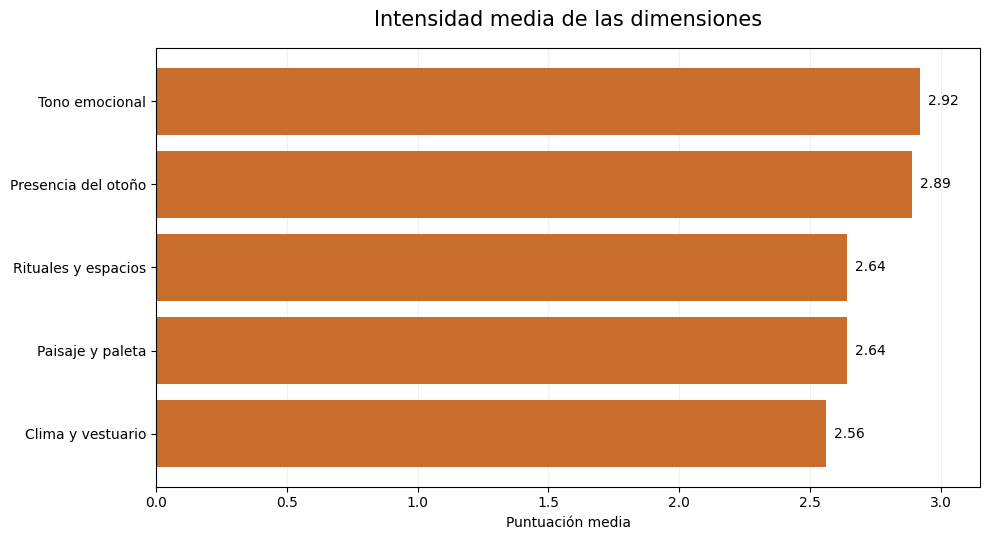

In [40]:
resumen_dimensiones_ordenado = resumen_dimensiones.sort_values(
    "media",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 5.5))

barras = ax.barh(
    resumen_dimensiones_ordenado.index,
    resumen_dimensiones_ordenado["media"],
    color="#c96d2d",
)

ax.bar_label(
    barras,
    fmt="%.2f",
    padding=6,
)

ax.set_title(
    "Intensidad media de las dimensiones",
    fontsize=15,
    pad=16,
)

ax.set_xlabel("Puntuación media")
ax.set_ylabel("")
ax.set_xlim(0, 3.15)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Análisis de sensibilidad del índice

El índice utiliza cinco dimensiones con el mismo peso. Aunque esta decisión facilita la interpretación, es necesario comprobar que la clasificación no depende excesivamente de una sola variable.

Para evaluarlo, recalculo el índice cinco veces, eliminando una dimensión en cada ocasión. Después comparo cada clasificación alternativa con la original y observo cuántas películas permanecen en el grupo superior de 90 puntos.

Una correlación próxima a 1 indicará que el orden general apenas cambia. Las entradas y salidas del grupo superior permitirán detectar qué dimensiones tienen mayor influencia sobre el umbral final.

In [41]:
ranking_original = ranking_refinado[
    "indice_otonalidad_refinado"
].rank(method="average", ascending=False)

ids_grupo_superior = set(
    grupo_superior["candidate_id"]
)

resultados_sensibilidad = []

for variable_excluida in variables_frontera:
    variables_restantes = [
        variable
        for variable in variables_frontera
        if variable != variable_excluida
    ]

    indice_alternativo = (
        ranking_refinado[variables_restantes].sum(axis=1)
        / (len(variables_restantes) * 3)
        * 100
    ).round(1)

    ranking_alternativo = indice_alternativo.rank(
        method="average",
        ascending=False,
    )

    ids_grupo_alternativo = set(
        ranking_refinado.loc[
            indice_alternativo >= 90,
            "candidate_id",
        ]
    )

    resultados_sensibilidad.append(
        {
            "dimensión_excluida": nombres_dimensiones[variable_excluida],
            "correlación_de_rangos": ranking_original.corr(
                ranking_alternativo
            ),
            "grupo_superior_mantenido": len(
                ids_grupo_superior & ids_grupo_alternativo
            ),
            "nuevas_incorporaciones": len(
                ids_grupo_alternativo - ids_grupo_superior
            ),
            "exclusiones": len(
                ids_grupo_superior - ids_grupo_alternativo
            ),
        }
    )

sensibilidad = pd.DataFrame(resultados_sensibilidad)

sensibilidad["correlación_de_rangos"] = sensibilidad[
    "correlación_de_rangos"
].round(3)

sensibilidad.sort_values(
    "correlación_de_rangos",
    ascending=False,
)

,dimensión_excluida,correlación_de_rangos,grupo_superior_mantenido,nuevas_incorporaciones,exclusiones
4,Tono emocional,0.986,6,0,12
2,Clima y vestuario,0.978,16,1,2
1,Paisaje y paleta,0.967,9,6,9
3,Rituales y espacios,0.936,11,2,7
0,Presencia del otoño,0.896,7,0,11


### Interpretación del análisis de sensibilidad

Las correlaciones de rangos son elevadas en todos los escenarios, con valores comprendidos entre 0,896 y 0,986. Esto indica que el orden general de las películas no depende exclusivamente de una dimensión y que el índice presenta una estabilidad razonable.

La presencia del otoño es la variable con mayor capacidad para alterar la clasificación: al eliminarla se obtiene la correlación más baja. Por el contrario, excluir el tono emocional apenas modifica el orden general, aunque provoca numerosas salidas del grupo superior porque esta dimensión recibe puntuaciones muy elevadas en casi todas las películas seleccionadas.

El clima y el vestuario son la dimensión menos determinante para pertenecer al grupo superior: 16 de las 18 películas permanecen por encima del umbral cuando se elimina.

Estos resultados también muestran que los 90 puntos deben interpretarse como un umbral editorial y no como una frontera objetiva. La clasificación es estable, pero la inclusión exacta de las películas empatadas en el límite depende de la definición del índice.

In [42]:
ranking_refinado["posicion"] = (
    ranking_refinado["indice_otonalidad_refinado"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

ranking_refinado = ranking_refinado.sort_values(
    [
        "indice_otonalidad_refinado",
        "titulo_castellano",
    ],
    ascending=[False, True],
).reset_index(drop=True)

columnas_exportacion = [
    "posicion",
    "candidate_id",
    "titulo_castellano",
    "titulo_original",
    "release_year",
    *variables_frontera,
    "indice_otonalidad_refinado",
    "confianza_refinada",
    "notas_revision",
]

ruta_ranking_refinado = DATA_DIR / "evaluaciones_otonalidad_refinadas.csv"
ruta_grupo_superior = DATA_DIR / "grupo_superior_otonalidad.csv"

ranking_refinado[columnas_exportacion].to_csv(
    ruta_ranking_refinado,
    index=False,
    encoding="utf-8-sig",
)

grupo_superior[columnas_exportacion].to_csv(
    ruta_grupo_superior,
    index=False,
    encoding="utf-8-sig",
)

resultado_exportacion = pd.Series(
    {
        "peliculas_refinadas": len(ranking_refinado),
        "peliculas_grupo_superior": len(grupo_superior),
        "archivo_evaluaciones": ruta_ranking_refinado.name,
        "archivo_grupo_superior": ruta_grupo_superior.name,
    }
)

resultado_exportacion

peliculas_refinadas                                           112
peliculas_grupo_superior                                       18
archivo_evaluaciones        evaluaciones_otonalidad_refinadas.csv
archivo_grupo_superior              grupo_superior_otonalidad.csv
dtype: object

## Conclusiones

El análisis comenzó con 265 películas candidatas. Tras excluir una película en la que Halloween constituía un elemento central, el índice se calculó inicialmente para 264 títulos.

La primera codificación permitió realizar un cribado general, pero produjo numerosos empates debido al uso de perfiles repetidos. Para mejorar la precisión, se efectuó una evaluación individual de 112 películas: las 66 seleccionadas inicialmente y otras 46 situadas cerca del umbral.

La clasificación definitiva identifica 18 películas con un índice de otoñalidad igual o superior a 90 puntos. *La tormenta de hielo* y *Las normas de la casa de la sidra* comparten la primera posición con 96,7 puntos. *Cuando cae el otoño* ocupa la segunda posición con 93,3 puntos, mientras que otras quince películas comparten el tercer puesto con 90 puntos.

El tono emocional es la dimensión más intensa del grupo superior, con una media de 2,92 puntos, seguida de la presencia explícita del otoño, con 2,89. El clima y el vestuario presentan la media más baja, con 2,56 puntos. Esto sugiere que la identidad otoñal de una película depende especialmente de su tono, su ambientación narrativa y su construcción visual, y no únicamente de la presencia de lluvia, frío o ropa de abrigo.

El análisis de sensibilidad obtiene correlaciones de rangos comprendidas entre 0,896 y 0,986. Por tanto, la clasificación general se mantiene relativamente estable cuando se elimina una dimensión. Sin embargo, la composición exacta del grupo superior es más sensible porque quince películas se encuentran exactamente en el umbral de 90 puntos.

En consecuencia, el índice debe entenderse como una herramienta editorial reproducible para comparar películas, no como una medición objetiva o definitiva de la otoñalidad. Sus resultados permiten identificar patrones, justificar la selección y hacer explícitos los criterios utilizados.